### KNN Classifier Model

This file focuses on predicting the success of a Kickstarter campaign using a K-Nearest Neighbors (KNN) model. The model initially achieved an accuracy of around 70%, which later improved to 77% after hyperparameter tuning and feature selection. The confusion matrix is also displayed, and the model is trained and evaluated on scaled data to ensure better performance.

In [1]:
%run data_prep.ipynb 

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import log_loss, accuracy_score

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

model = KNeighborsClassifier()
model.fit(X_train, y_train)

probabilities = model.predict_proba(X_test)
y_pred = model.predict(X_test)

print("Log Loss:", log_loss(y_test, probabilities))
print("Accuracy:", accuracy_score(y_test, y_pred))


Log Loss: 1.7329108458233355
Accuracy: 0.6991481404529399


In [3]:
from sklearn.metrics import accuracy_score, f1_score, make_scorer
from sklearn.model_selection import train_test_split, GridSearchCV
param_grid = {
    'n_neighbors': [5, 10, 15, 25],
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}
scoring = {'accuracy': 'accuracy', 'f1_macro': make_scorer(f1_score, average='macro')}

grid = GridSearchCV(KNeighborsClassifier(), param_grid, scoring=scoring, refit='f1_macro', cv=5, n_jobs=-1)
grid.fit(X_train, y_train)

# evaluate results
print("best parameters:", grid.best_params_)
print(f"best cv f1-score: {grid.best_score_:.3f}")

y_pred = grid.best_estimator_.predict(X_test)
print(f"test accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"test f1-score: {f1_score(y_test, y_pred, average='macro'):.3f}")

best parameters: {'n_neighbors': 15, 'p': 1, 'weights': 'distance'}
best cv f1-score: 0.707
test accuracy: 0.717
test f1-score: 0.713


Confusion Matrix:
[[2879 1479]
 [1245 4023]]


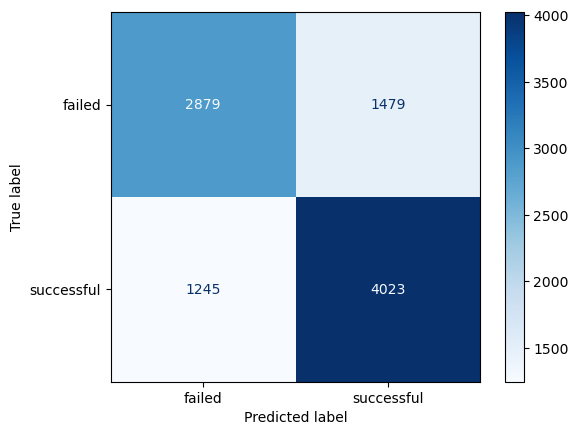

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

grid = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
grid.plot(cmap='Blues') 


In [ ]:
# Save the best model- file created and moved to saved_models folder
# import pickle
# with open('knn_model.pkl', 'wb') as f:
#     pickle.dump(grid.best_estimator_, f)